In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from datetime import datetime
import plotly.express as px
from datetime import datetime

mpl.rc('font',family='Malgun Gothic')

In [21]:
df = pd.read_csv('oil_price.csv')

In [22]:
df

,번호,지역,상호,주소,기간,상표,셀프여부,고급휘발유,휘발유,경유,실내등유
0,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022년 01월 1주,현대오일뱅크,셀프,1769.00,1543.00,1375.86,0.00
1,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022년 01월 2주,현대오일뱅크,셀프,1769.00,1543.00,1368.00,0.00
2,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022년 01월 3주,현대오일뱅크,셀프,1769.00,1568.00,1389.43,0.00
3,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022년 01월 4주,현대오일뱅크,셀프,1777.57,1579.43,1408.71,0.00
4,A0011352,강원 강릉시,(주)대성길,강원 강릉시 구정면 칠성로 187,2022년 01월 1주,S-OIL,셀프,0.00,1599.00,1449.00,1080.00
...,...,...,...,...,...,...,...,...,...,...,...
574037,A0016900,충북 충주시,황제주유소,충북 충주시 신니면 중원대로 5775,2022년 12월 4주,GS칼텍스,셀프,0.00,1490.86,1705.14,1350.00
574038,A0013418,충북 충주시,희망주유소,충북 충주시 금봉대로 398,2022년 12월 1주,GS칼텍스,셀프,0.00,1568.00,1779.43,1478.57
574039,A0013418,충북 충주시,희망주유소,충북 충주시 금봉대로 398,2022년 12월 2주,GS칼텍스,셀프,0.00,1508.00,1716.57,1450.00
574040,A0013418,충북 충주시,희망주유소,충북 충주시 금봉대로 398,2022년 12월 3주,GS칼텍스,셀프,0.00,1485.14,1680.86,1428.57


In [23]:
df = pd.read_csv("oil_price.csv")
df = df.rename(columns={
    '번호': 'id',
    '지역': 'region',
    '상호': 'store_name', 
    '주소': 'address',
    '기간': 'period',
    '상표': 'brand',
    '셀프여부': 'is_self',
    '고급휘발유': 'premium_gas',
    '휘발유': 'regular_gas',
    '경유': 'diesel',
    '실내등유': 'kerosene'
})

for week_num, date_name in enumerate(sorted(df.period.unique()), start=1):
    name = date_name.split()
    year, month = int(name[0][:4]), int(name[1][:2])

    date = datetime.strptime(f"{year}-{month}-0-{week_num}", "%Y-%m-%w-%U")

    df.loc[df['period'] == date_name, 'period'] = date

df.head(2)

,id,region,store_name,address,period,brand,is_self,premium_gas,regular_gas,diesel,kerosene
0,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-02 00:00:00,현대오일뱅크,셀프,1769.0,1543.0,1375.86,0.0
1,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-09 00:00:00,현대오일뱅크,셀프,1769.0,1543.0,1368.00,0.0


In [24]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
df = df.drop(columns=['id','address','kerosene'])

In [28]:
# %%time # 소요시간 측정  (%%~ 형식으로 다양한 기능 다룰 수 있음)
df.loc[df.premium_gas == 0, 'premium_gas'] = None # 0인 값을 None으로 변환 
df

,region,store_name,period,brand,is_self,premium_gas,regular_gas,diesel
0,강원 강릉시,(주)강릉햇살 유천주유소,2022-01-02 00:00:00,현대오일뱅크,셀프,1769.00,1543.00,1375.86
1,강원 강릉시,(주)강릉햇살 유천주유소,2022-01-09 00:00:00,현대오일뱅크,셀프,1769.00,1543.00,1368.00
2,강원 강릉시,(주)강릉햇살 유천주유소,2022-01-16 00:00:00,현대오일뱅크,셀프,1769.00,1568.00,1389.43
3,강원 강릉시,(주)강릉햇살 유천주유소,2022-01-23 00:00:00,현대오일뱅크,셀프,1777.57,1579.43,1408.71
4,강원 강릉시,(주)대성길,2022-01-02 00:00:00,S-OIL,셀프,NaN,1599.00,1449.00
...,...,...,...,...,...,...,...,...
574037,충북 충주시,황제주유소,2022-12-25 00:00:00,GS칼텍스,셀프,NaN,1490.86,1705.14
574038,충북 충주시,희망주유소,2022-12-04 00:00:00,GS칼텍스,셀프,NaN,1568.00,1779.43
574039,충북 충주시,희망주유소,2022-12-11 00:00:00,GS칼텍스,셀프,NaN,1508.00,1716.57
574040,충북 충주시,희망주유소,2022-12-18 00:00:00,GS칼텍스,셀프,NaN,1485.14,1680.86


In [29]:
df.premium_gas.describe()


count    67574.000000
mean      2061.536722
std        194.337823
min       1517.570000
25%       1899.430000
50%       2048.290000
75%       2197.000000
max       3485.290000
Name: premium_gas, dtype: float64

In [30]:
df['region'].unique()


array(['강원 강릉시', '강원 고성군', '강원 동해시', '강원 삼척시', '강원 속초시', '강원 양구군',
       '강원 양양군', '강원 영월군', '강원 원주시', '강원 인제군', '강원 정선군', '강원 철원군',
       '강원 춘천시', '강원 태백시', '강원 평창군', '강원 홍천군', '강원 화천군', '강원 횡성군',
       '경기 가평군', '경기 고양시', '경기 과천시', '경기 광명시', '경기 광주시', '경기 구리시',
       '경기 군포시', '경기 김포시', '경기 남양주시', '경기 동두천시', '경기 부천시', '경기 성남시',
       '경기 수원시', '경기 시흥시', '경기 안산시', '경기 안성시', '경기 안양시', '경기 양주시',
       '경기 양평군', '경기 여주시', '경기 연천군', '경기 오산시', '경기 용인시', '경기 의왕시',
       '경기 의정부시', '경기 이천시', '경기 파주시', '경기 평택시', '경기 포천시', '경기 하남시',
       '경기 화성시', '경남 거제시', '경남 거창군', '경남 고성군', '경남 김해시', '경남 남해군',
       '경남 밀양시', '경남 사천시', '경남 산청군', '경남 양산시', '경남 의령군', '경남 진주시',
       '경남 창녕군', '경남 창원시', '경남 통영시', '경남 하동군', '경남 함안군', '경남 함양군',
       '경남 합천군', '경북 경산시', '경북 경주시', '경북 고령군', '경북 구미시', '경북 군위군',
       '경북 김천시', '경북 문경시', '경북 봉화군', '경북 상주시', '경북 성주군', '경북 안동시',
       '경북 영덕군', '경북 영양군', '경북 영주시', '경북 영천시', '경북 예천군', '경북 울릉군',
       '경북 울진군', '경북 의성군', '경북 청도군', '경북 청송군', '경북 칠곡군', '경

In [34]:
for r in df.region.unique():
    if len(r.split()) != 2:
        print(r)


In [33]:
df.loc[df.region == '세종시', 'region'] = '충남 세종시'

In [38]:
df['city'] = df.region.str.split().str[0]
df['gu'] = df.region.str.split().str[1]


In [40]:
df.head(2)



,region,store_name,period,brand,is_self,premium_gas,regular_gas,diesel,city,gu
0,강원 강릉시,(주)강릉햇살 유천주유소,2022-01-02 00:00:00,현대오일뱅크,셀프,1769.0,1543.0,1375.86,강원,강릉시
1,강원 강릉시,(주)강릉햇살 유천주유소,2022-01-09 00:00:00,현대오일뱅크,셀프,1769.0,1543.0,1368.00,강원,강릉시


In [44]:
# len(df[df.regular_gas == 0])
df[df.regular_gas == 0].shape


(2067, 10)

In [45]:
df.loc[df.regular_gas == 0, 'regular_gas'] = None
df.loc[df.diesel == 0, 'diesel'] = None


In [46]:
df.is_self.unique()


array(['셀프', '일반'], dtype=object)

In [47]:
df['is_self'] = df['is_self'].map({'셀프': True, '일반': False})


In [49]:
df = df.drop(columns=['region'])


# 시각화

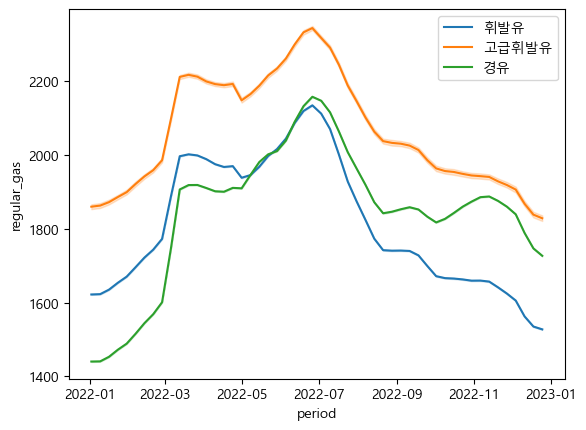

In [54]:
sns.lineplot(x='period', y='regular_gas', data=df, label='휘발유')
sns.lineplot(x='period', y='premium_gas', data=df, label='고급휘발유')
sns.lineplot(x='period', y='diesel', data=df, label='경유')

plt.legend()
plt.show()







In [59]:
# brand 점유율
brand_ratios = df['brand'].value_counts(normalize=True) * 100
# brand_ratios = brand_counts / len(df) * 100
brand_ratios


brand
SK에너지     26.564084
현대오일뱅크    21.497033
GS칼텍스     19.849593
S-OIL     19.301027
NH-OIL     6.026737
알뜰주유소      3.914348
알뜰(ex)     1.703708
자가상표       1.143470
Name: proportion, dtype: float64

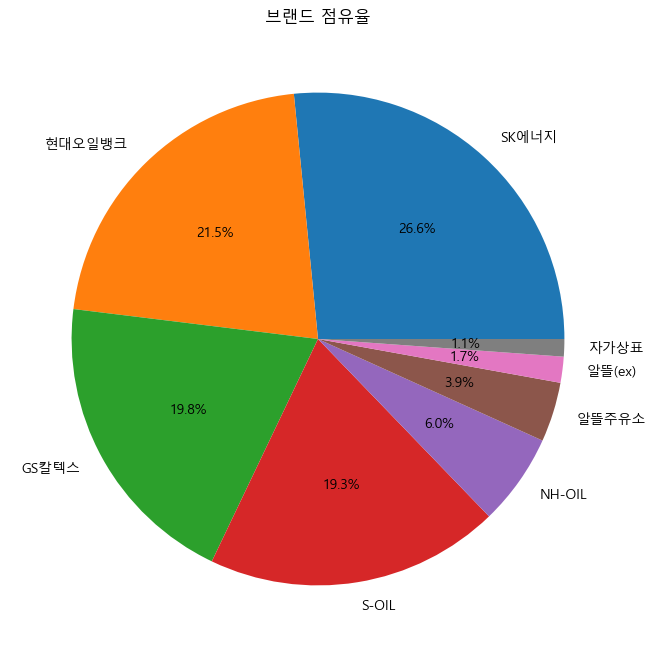

In [77]:
plt.figure(figsize=(10, 8))
plt.pie(brand_ratios, labels=brand_ratios.index, autopct='%1.1f%%')
plt.title('브랜드 점유율')
plt.show()

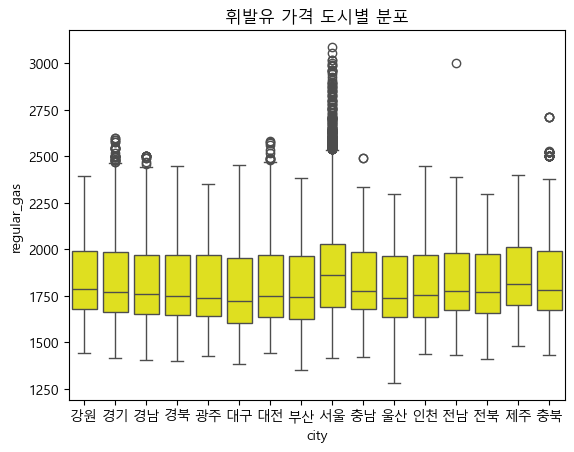

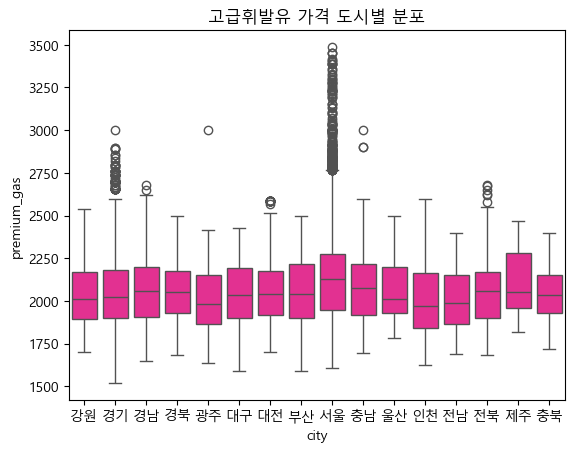

In [80]:
sns.boxplot(x='city', y='regular_gas', data=df, color='yellow')
plt.title('휘발유 가격 도시별 분포')
plt.show()
sns.boxplot(x='city', y='premium_gas', data=df, color='deeppink')
plt.title('고급휘발유 가격 도시별 분포')
plt.show()

In [83]:
# 도시별 월별 평균 가격 
# freq='M' : 월별 평균 가격
# freq='Q' : 분기별 평균 가격
# freq='Y' : 연도별 평균 가격   
oil_by_regional_monthly = df.groupby(
    ['city',pd.Grouper(key='period', freq='M')]).mean(
        numeric_only=True).reset_index()
oil_by_regional_monthly


,city,period,is_self,premium_gas,regular_gas,diesel
0,강원,2022-01-31,0.398819,1869.037303,1649.491493,1479.170407
1,강원,2022-02-28,0.399378,1935.528395,1733.763481,1563.573129
2,강원,2022-03-31,0.397670,2144.925083,1959.633430,1864.967825
3,강원,2022-04-30,0.399767,2165.799317,1984.209416,1920.516523
4,강원,2022-05-31,0.400559,2161.707262,1982.524173,1980.798012
...,...,...,...,...,...,...
187,충북,2022-08-31,0.448935,2048.220172,1781.484603,1875.771494
188,충북,2022-09-30,0.452045,2014.672686,1738.731109,1855.208924
189,충북,2022-10-31,0.456120,1969.517593,1674.938577,1852.074298
190,충북,2022-11-30,0.456084,1941.476444,1655.359895,1884.533038


In [84]:
oil_by_regional_monthly.period.unique()


<DatetimeArray>
['2022-01-31 00:00:00', '2022-02-28 00:00:00', '2022-03-31 00:00:00',
 '2022-04-30 00:00:00', '2022-05-31 00:00:00', '2022-06-30 00:00:00',
 '2022-07-31 00:00:00', '2022-08-31 00:00:00', '2022-09-30 00:00:00',
 '2022-10-31 00:00:00', '2022-11-30 00:00:00', '2022-12-31 00:00:00']
Length: 12, dtype: datetime64[ns]

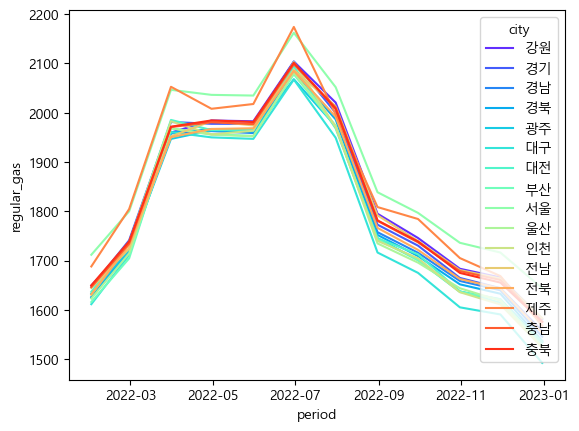

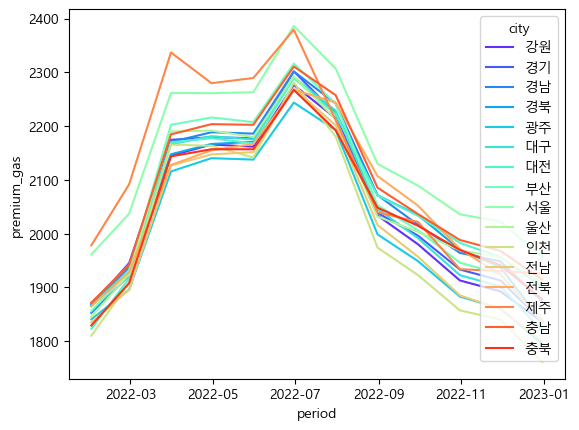

In [89]:
sns.lineplot(data=oil_by_regional_monthly, x='period', y='regular_gas', hue='city', palette='rainbow')
plt.show()

sns.lineplot(data=oil_by_regional_monthly, x='period', y='premium_gas', hue='city', palette='rainbow')
plt.show()

In [95]:
sihung_df = df[df['gu'] == '시흥시']
sihung_df = sihung_df.dropna(subset=['regular_gas','premium_gas','diesel'])
sihung_df

,store_name,period,brand,is_self,premium_gas,regular_gas,diesel,city,gu
5653,(주)세지에너지주유소/충전소,2022-01-02 00:00:00,SK에너지,True,1815.00,1619.00,1439.00,경기,시흥시
5654,(주)세지에너지주유소/충전소,2022-01-09 00:00:00,SK에너지,True,1815.00,1619.00,1439.00,경기,시흥시
5655,(주)세지에너지주유소/충전소,2022-01-16 00:00:00,SK에너지,True,1815.00,1630.43,1450.43,경기,시흥시
5656,(주)세지에너지주유소/충전소,2022-01-23 00:00:00,SK에너지,True,1827.86,1653.29,1473.29,경기,시흥시
5661,(주)시흥에너지 배곧주유소,2022-01-02 00:00:00,SK에너지,True,1797.00,1587.00,1417.00,경기,시흥시
...,...,...,...,...,...,...,...,...,...
536034,현대오일뱅크㈜직영 목감주유소,2022-12-25 00:00:00,현대오일뱅크,True,1753.00,1548.00,1749.43,경기,시흥시
536035,효창에너지직영 5주유소,2022-12-04 00:00:00,SK에너지,True,1731.86,1522.71,1772.71,경기,시흥시
536036,효창에너지직영 5주유소,2022-12-11 00:00:00,SK에너지,True,1697.86,1478.71,1711.57,경기,시흥시
536037,효창에너지직영 5주유소,2022-12-18 00:00:00,SK에너지,True,1665.57,1459.86,1687.00,경기,시흥시


In [106]:
sihung_df.store_name.value_counts().reset_index()


,store_name,count
0,(주)세지에너지주유소/충전소,52
1,월곶하이웨이주유소,52
2,현대오일뱅크㈜직영 목감주유소,52
3,현대오일뱅크(주)직영 신천리주유소,52
4,현대오일뱅크(주)직영 능곡현대주유소,52
5,하우고개주유소,52
6,지에스칼텍스㈜ 시화신도시주유소,52
7,지에스칼텍스㈜ 시화공단주유소,52
8,지에스칼텍스(주)시흥대한주유소,52
9,신월곶주유소,52


In [ ]:
# 주별 최저 가격 추출
min_premium_by_week = sihung_df.loc[sihung_df.groupby('period')['premium_gas'].idxmin()]
min_premium_by_week
